In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def calculate_pool_value(price, pa, pb, l):
    """Рассчитывает стоимость пула при заданной цене ТОЛЬКО по формуле V3"""
    if l <= 0:
        return 0.0
    sqrt_price = np.sqrt(price)
    sqrt_pa = np.sqrt(pa)
    sqrt_pb = np.sqrt(pb)
    if price <= pa:
        pool_eth = l * (1/sqrt_pa - 1/sqrt_pb)
        return pool_eth * price
    elif price >= pb:
        return l * (sqrt_pb - sqrt_pa)
    else:
        pool_usdc = l * (sqrt_price - sqrt_pa)
        pool_eth = l * (1/sqrt_price - 1/sqrt_pb)
        return pool_usdc + pool_eth * price

In [3]:
def calculate_liquidity(capital_amount, pn_price, pa_price, pb_price):
    """Правильная формула ликвидности для Uniswap V3"""
    # if pn_price <= pa_price or pn_price >= pb_price:
    #     pn_price = (pa_price + pb_price) / 2
    
    sqrt_pn = np.sqrt(pn_price)
    sqrt_pa = np.sqrt(pa_price)
    sqrt_pb = np.sqrt(pb_price)
    
    term1 = sqrt_pn - sqrt_pa
    term2 = pn_price * (1/sqrt_pn - 1/sqrt_pb)
    if (term1 + term2) == 0:
        return 0.0
    
    l = capital_amount / (term1 + term2)
    
    # if verbose_logging and abs(calculate_pool_value(pn_price, pa_price, pb_price, l) - capital_amount) > capital_amount * 0.01:
    #     print(f"  Внимание: разница в расчетах. Capital=${capital_amount:.2f}, Pool Value at Pn=${calculate_pool_value(pn_price, pa_price, pb_price, l):.2f}")
    return l

In [17]:
capital_amount = 100
pa_price =200
pb_price = 600

pn_price = 800

ls = [pn_price,900,800,700,600,500,400,300,200,100,10]
ls_out=[]
for pn in ls:
    print(pn,calculate_liquidity(capital_amount, pn, pa_price, pb_price))
    ls_out.append(calculate_liquidity(capital_amount, pn, pa_price, pb_price))


800 10.23903683295026
900 10.970303325299712
800 10.23903683295026
700 9.808238862001959
600 9.659258262890683
500 9.835927480826685
400 10.495456101852998
300 12.119108811345459
200 16.73032607475616
100 56.32592296244092
10 -12.156830021314398


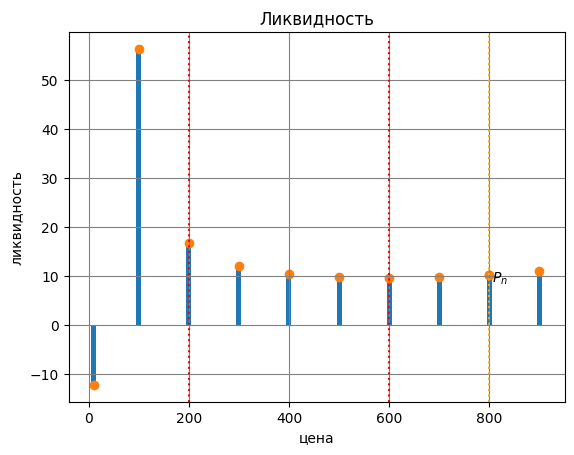

In [18]:
width = 10       #Задаём ширину столбцов
# fig, ax = plt.subplots()

plt.title("Ликвидность")
plt.xlabel('цена')
plt.ylabel('ликвидность')
plt.axvline(x=pa_price, color="r", linestyle=":", label="Pa")
plt.axvline(x=pb_price, color="r", linestyle=":", label="Pb")
plt.axvline(x=pn_price, color="orange", linestyle=":", label="Pn")
plt.annotate("$P_{n}$", (pn_price+5, 0.87*10))
# plt.plot(ls, ls_out, color="blue", label="Ликвидность")
plt.bar(ls, ls_out, width)#, color="blue", label="Ликвидность")
plt.scatter(ls, ls_out)
# plt.plot(data_out['step'], data_out['Size Pool'], color="orange", label="Цена")
plt.grid(True, color="gray")
plt.show()

# Блок схемы

